# 02 Data Assessing

## Ringkasan awal dataset dan rencana cleaning

mengecek 8 dataset hasil data gathering sebelum masuk ke tahap cleaning.

Dataset yang dicek:
- 6 dataset e-commerce: Januari 2024, Juni 2024, Desember 2024, Februari 2025, Juli 2025, November 2025.
- 1 dataset daily household transaction.
- 1 dataset personal finance.

Hal utama yang perlu dicek di notebook ini:
- Struktur kolom tiap dataset, karena e-commerce berbeda dari household dan personal finance.
- Missing value, terutama tanggal, amount, kategori, status, lokasi, dan alasan pembatalan.
- Duplikasi data, baik duplikat persis maupun duplikat berdasarkan key transaksi.
- Statistik deskriptif amount: min, Q1, median, Q3, IQR, mean, max.
- Outlier amount dengan metode IQR per dataset, bukan digabung langsung karena skala amount berbeda.
- Pola khusus per dataset: e-commerce punya status pesanan dan order id, household punya mode pembayaran dan income/expense, personal finance punya type dan deskripsi transaksi.

Yang harus dilakukan di `03_data_cleaning.ipynb`:
- Standarkan semua dataset ke kolom final seperti `timestamp`, `amount`, `category`, `description`, `payment_method`, `city`, `province`, `quantity`, dan `order_id`.
- Parse tanggal dengan format campuran. Dataset e-commerce Desember 2024 dan Juli 2025 tidak punya kolom `Waktu Pesanan Dibuat`, jadi tanggal perlu diambil dari periode dataset.
- Buang atau tandai transaksi e-commerce yang `Status Pesanan = Batal` atau amount bernilai 0.
- Tangani duplikasi dan outlier amount berdasarkan hasil IQR di notebook ini.
- Samakan kategori dan mata uang sebelum dataset digabung.


## 1. Import library

Library dibuat sedikit saja agar notebook mudah dibaca. `pandas` untuk tabel, `numpy` untuk angka, dan `matplotlib` untuk visualisasi sederhana.


In [1]:
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Konfigurasi path

Notebook ini bisa membaca data dari dua kondisi:
- Struktur project lokal: file ada di `data/interim/raw_separate`.
- Google Colab: 8 file dataset diletakkan langsung di root/current folder, misalnya `/content`.


In [2]:
project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

local_raw_separate_path = project_root / 'data' / 'interim' / 'raw_separate'
local_raw_path = project_root / 'data' / 'raw'
colab_root_path = Path('/content') if Path('/content').exists() else None

candidate_data_paths = [
    local_raw_separate_path,
    project_root,
    local_raw_path,
    local_raw_path / 'Indonesian_Ecommerce_sales',
    local_raw_path / 'daily_household_transaction',
    local_raw_path / 'personal_finance',
]
if colab_root_path is not None and colab_root_path not in candidate_data_paths:
    candidate_data_paths.append(colab_root_path)

candidate_data_paths = list(dict.fromkeys(candidate_data_paths))

interim_path = project_root / 'data' / 'interim'
reports_path = project_root / 'reports'

interim_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print('Project root       :', project_root)
print('Local data path    :', local_raw_separate_path)
print('Raw data path      :', local_raw_path)
print('Colab root path    :', colab_root_path)
print('Candidate paths    :')
for path in candidate_data_paths:
    print('-', path)


Project root       : /home/umaygans/05_nayyara_submission_1/nayyara_capstone
Local data path    : /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/interim/raw_separate
Raw data path      : /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw
Colab root path    : None
Candidate paths    :
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/interim/raw_separate
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw/Indonesian_Ecommerce_sales
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw/daily_household_transaction
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw/personal_finance


## 3. Daftar 8 dataset

Cell ini mencari 8 dataset utama. Jika notebook dijalankan di Colab, cukup upload atau letakkan 8 file dataset langsung di root/current folder. Nama file yang dikenali adalah nama raw asli dan nama CSV hasil data gathering.


In [3]:
DATASET_CATALOG = [
    {
        'dataset_id': 'ecommerce_2024_01_january',
        'dataset_name': 'E-Commerce Sales - January 2024',
        'domain': 'ecommerce_sales',
        'period': '2024-01',
        'possible_files': ['ecommerce_2024_01_january.csv', '01_JanuarySales2024_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2024_06_june',
        'dataset_name': 'E-Commerce Sales - June 2024',
        'domain': 'ecommerce_sales',
        'period': '2024-06',
        'possible_files': ['ecommerce_2024_06_june.csv', '02_JuneSales2024_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2024_12_december',
        'dataset_name': 'E-Commerce Sales - December 2024',
        'domain': 'ecommerce_sales',
        'period': '2024-12',
        'possible_files': ['ecommerce_2024_12_december.csv', '03_DecemberSales2024_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2025_02_february',
        'dataset_name': 'E-Commerce Sales - February 2025',
        'domain': 'ecommerce_sales',
        'period': '2025-02',
        'possible_files': ['ecommerce_2025_02_february.csv', '04_FebruarySales2025_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2025_07_july',
        'dataset_name': 'E-Commerce Sales - July 2025',
        'domain': 'ecommerce_sales',
        'period': '2025-07',
        'possible_files': ['ecommerce_2025_07_july.csv', '05_JulySales2025_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2025_11_november',
        'dataset_name': 'E-Commerce Sales - November 2025',
        'domain': 'ecommerce_sales',
        'period': '2025-11',
        'possible_files': ['ecommerce_2025_11_november.csv', '06_NovemberSales2025_clean.xlsx'],
    },
    {
        'dataset_id': 'daily_household_transactions',
        'dataset_name': 'Daily Household Transactions',
        'domain': 'household_finance',
        'period': pd.NA,
        'possible_files': ['daily_household_transactions.csv', 'Daily Household Transactions.csv'],
    },
    {
        'dataset_id': 'personal_finance',
        'dataset_name': 'Personal Finance Dataset',
        'domain': 'personal_finance',
        'period': pd.NA,
        'possible_files': ['personal_finance.csv', 'Personal_Finance_Dataset.csv'],
    },
]


def cari_file_dataset(meta, data_paths):
    for data_path in data_paths:
        for file_name in meta['possible_files']:
            file_path = data_path / file_name
            if file_path.exists():
                return file_path

    for data_path in data_paths:
        if not data_path.exists():
            continue
        for file_name in meta['possible_files']:
            matches = [path for path in data_path.rglob(file_name) if '.ipynb_checkpoints' not in str(path)]
            if matches:
                return sorted(matches)[0]

    return None


def path_ringkas(file_path):
    try:
        return str(file_path.relative_to(project_root))
    except ValueError:
        return str(file_path)


dataset_rows = []
missing_files = []

for meta in DATASET_CATALOG:
    file_path = cari_file_dataset(meta, candidate_data_paths)
    if file_path is None:
        missing_files.append(meta['dataset_id'])
        continue

    dataset_rows.append({
        'dataset_id': meta['dataset_id'],
        'dataset_name': meta['dataset_name'],
        'domain': meta['domain'],
        'period': meta['period'],
        'file_name': file_path.name,
        'file_path': file_path,
        'file_path_display': path_ringkas(file_path),
    })

if missing_files:
    raise FileNotFoundError(
        'Dataset berikut belum ditemukan di folder lokal atau root Colab: ' + ', '.join(missing_files)
    )

dataset_files_df = pd.DataFrame(dataset_rows)
display(dataset_files_df.drop(columns='file_path'))


,dataset_id,dataset_name,domain,period,file_name,file_path_display
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,2024-01,01_JanuarySales2024_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/01_January...
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,2024-06,02_JuneSales2024_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/02_JuneSal...
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,2024-12,03_DecemberSales2024_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/03_Decembe...
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,2025-02,04_FebruarySales2025_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/04_Februar...
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,2025-07,05_JulySales2025_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/05_JulySal...
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,2025-11,06_NovemberSales2025_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/06_Novembe...
6,daily_household_transactions,Daily Household Transactions,household_finance,<NA>,Daily Household Transactions.csv,data/raw/daily_household_transaction/Daily Hou...
7,personal_finance,Personal Finance Dataset,personal_finance,<NA>,Personal_Finance_Dataset.csv,data/raw/personal_finance/Personal_Finance_Dat...


## 4. Load semua dataset

Setiap file disimpan dalam dictionary `raw_datasets`. Jika file berasal dari root Colab dan belum punya metadata `_dataset_id`, metadata akan ditambahkan otomatis dari catalog.


,dataset_id,dataset_name,domain,period,source_file,rows,columns
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,2024-01,01_JanuarySales2024_clean.xlsx,431,24
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,2024-06,02_JuneSales2024_clean.xlsx,697,24
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,2024-12,03_DecemberSales2024_clean.xlsx,1214,23
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,2025-02,04_FebruarySales2025_clean.xlsx,957,24
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,2025-07,05_JulySales2025_clean.xlsx,766,23
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,2025-11,06_NovemberSales2025_clean.xlsx,1131,24
6,daily_household_transactions,Daily Household Transactions,household_finance,<NA>,Daily Household Transactions.csv,2461,14
7,personal_finance,Personal Finance Dataset,personal_finance,<NA>,Personal_Finance_Dataset.csv,1500,11


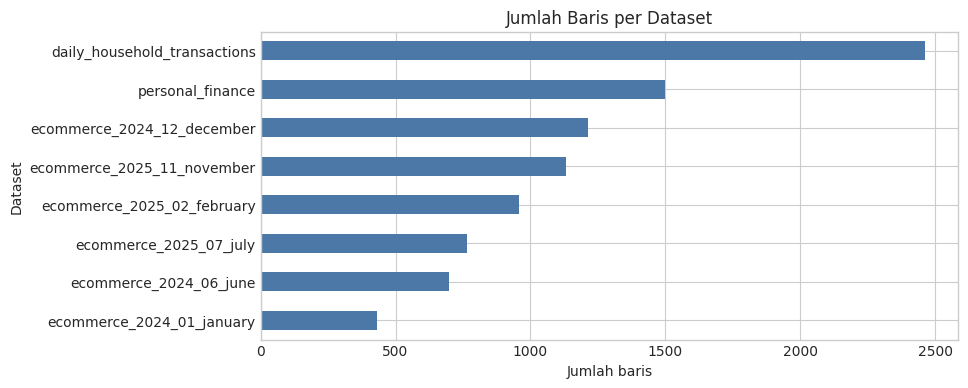

In [4]:
def make_unique_columns(columns):
    seen = {}
    unique_columns = []

    for index, column in enumerate(columns):
        column_name = str(column).strip() if pd.notna(column) and str(column).strip() else f'column_{index + 1}'
        if column_name in seen:
            seen[column_name] += 1
            column_name = f'{column_name}_{seen[column_name]}'
        else:
            seen[column_name] = 0
        unique_columns.append(column_name)

    return unique_columns


def excel_column_index(cell_reference):
    letters = ''.join(character for character in cell_reference if character.isalpha())
    index = 0
    for character in letters:
        index = index * 26 + ord(character.upper()) - ord('A') + 1
    return index - 1


def read_excel_without_engine(file_path):
    namespace = {'main': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    with ZipFile(file_path) as workbook:
        shared_strings = []
        if 'xl/sharedStrings.xml' in workbook.namelist():
            root = ET.fromstring(workbook.read('xl/sharedStrings.xml'))
            for item in root.findall('main:si', namespace):
                texts = [text.text or '' for text in item.findall('.//main:t', namespace)]
                shared_strings.append(''.join(texts))

        sheet_name = sorted(name for name in workbook.namelist() if name.startswith('xl/worksheets/sheet'))[0]
        root = ET.fromstring(workbook.read(sheet_name))
        rows = []

        for row in root.findall('.//main:row', namespace):
            values = []
            for cell in row.findall('main:c', namespace):
                column_index = excel_column_index(cell.attrib.get('r', 'A1'))
                while len(values) <= column_index:
                    values.append(np.nan)

                cell_type = cell.attrib.get('t')
                value_node = cell.find('main:v', namespace)

                if cell_type == 'inlineStr':
                    texts = [text.text or '' for text in cell.findall('.//main:t', namespace)]
                    value = ''.join(texts) if texts else np.nan
                elif value_node is None:
                    value = np.nan
                elif cell_type == 's':
                    value = shared_strings[int(value_node.text)]
                else:
                    value = value_node.text

                values[column_index] = value
            rows.append(values)

    if not rows:
        return pd.DataFrame()

    max_columns = max(len(row) for row in rows)
    rows = [row + [np.nan] * (max_columns - len(row)) for row in rows]
    return pd.DataFrame(rows[1:], columns=make_unique_columns(rows[0])).replace(r'^\s*$', np.nan, regex=True)


def baca_file_dataset(file_path):
    if file_path.suffix.lower() == '.csv':
        return pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8-sig').replace(r'^\s*$', np.nan, regex=True)
    if file_path.suffix.lower() in ['.xlsx', '.xls']:
        try:
            return pd.read_excel(file_path).replace(r'^\s*$', np.nan, regex=True)
        except ImportError:
            return read_excel_without_engine(file_path)
    raise ValueError(f'Format file belum didukung: {file_path.name}')


def tambah_metadata(frame, row):
    hasil = frame.copy()
    hasil['_dataset_id'] = hasil.get('_dataset_id', row['dataset_id'])
    hasil['_dataset_name'] = hasil.get('_dataset_name', row['dataset_name'])
    hasil['_domain'] = hasil.get('_domain', row['domain'])
    hasil['_dataset_period'] = hasil.get('_dataset_period', row['period'])
    hasil['_source_file'] = hasil.get('_source_file', row['file_name'])
    hasil['_source_path'] = hasil.get('_source_path', row['file_path_display'])
    return hasil


raw_datasets = {}
load_rows = []

for _, row in dataset_files_df.iterrows():
    frame = baca_file_dataset(row['file_path'])
    frame = tambah_metadata(frame, row)
    dataset_id = row['dataset_id']
    raw_datasets[dataset_id] = frame
    load_rows.append({
        'dataset_id': dataset_id,
        'dataset_name': row['dataset_name'],
        'domain': row['domain'],
        'period': row['period'],
        'source_file': row['file_name'],
        'rows': len(frame),
        'columns': frame.shape[1],
    })

load_summary_df = pd.DataFrame(load_rows)
display(load_summary_df)

ax = load_summary_df.sort_values('rows').plot(
    x='dataset_id', y='rows', kind='barh', legend=False, figsize=(9, 4), color='#4c78a8'
)
ax.set_title('Jumlah Baris per Dataset')
ax.set_xlabel('Jumlah baris')
ax.set_ylabel('Dataset')
plt.show()


## 5. Cek struktur kolom

Bagian ini melihat apakah skema kolom antar dataset sama atau berbeda. Hasilnya penting untuk menentukan function khusus per pola dataset.


In [5]:
column_rows = []

for dataset_id, frame in raw_datasets.items():
    for column in frame.columns:
        column_rows.append({
            'dataset_id': dataset_id,
            'column': column,
            'dtype': str(frame[column].dtype),
            'missing_pct': round(frame[column].isna().mean() * 100, 2),
        })

column_check_df = pd.DataFrame(column_rows)
common_columns = (
    column_check_df.groupby('column')['dataset_id']
    .nunique()
    .reset_index(name='appears_in_dataset_count')
    .sort_values(['appears_in_dataset_count', 'column'], ascending=[False, True])
)

display(common_columns)

print('Contoh kolom per dataset:')
for dataset_id, frame in raw_datasets.items():
    print('')
    print(dataset_id)
    print(list(frame.columns))


,column,appears_in_dataset_count
22,_dataset_id,8
23,_dataset_name,8
24,_dataset_period,8
25,_domain,8
26,_source_file,8
27,_source_path,8
0,Alasan Pembatalan,6
5,Estimasi Potongan Biaya Pengiriman,6
7,Kota/Kabupaten,6
8,Metode Pembayaran,6


Contoh kolom per dataset:

ecommerce_2024_01_january
['order_id', 'total_qty', 'total_weight_gr', 'total_returned_qty', 'Total Diskon', 'product_categories', 'num_product_categories', 'Status Pesanan', 'Alasan Pembatalan', 'Opsi Pengiriman', 'Metode Pembayaran', 'Kota/Kabupaten', 'Provinsi', 'Ongkos Kirim Dibayar oleh Pembeli', 'Estimasi Potongan Biaya Pengiriman', 'Total Pembayaran', 'Perkiraan Ongkos Kirim', 'Waktu Pesanan Dibuat', '_dataset_id', '_dataset_name', '_domain', '_dataset_period', '_source_file', '_source_path']

ecommerce_2024_06_june
['order_id', 'total_qty', 'total_weight_gr', 'total_returned_qty', 'Total Diskon', 'product_categories', 'num_product_categories', 'Status Pesanan', 'Alasan Pembatalan', 'Opsi Pengiriman', 'Metode Pembayaran', 'Kota/Kabupaten', 'Provinsi', 'Ongkos Kirim Dibayar oleh Pembeli', 'Estimasi Potongan Biaya Pengiriman', 'Total Pembayaran', 'Perkiraan Ongkos Kirim', 'Waktu Pesanan Dibuat', '_dataset_id', '_dataset_name', '_domain', '_dataset_period

## 6. Function sederhana sesuai pola dataset

Karena ada 3 pola data, function-nya dipisah:
- `siapkan_ecommerce`: untuk 6 dataset penjualan e-commerce.
- `siapkan_household`: untuk daily household transaction.
- `siapkan_personal_finance`: untuk personal finance.

Output ketiganya dibuat seragam agar analisis missing, duplikat, statistik, dan outlier bisa dilakukan dengan cara yang sama.


In [6]:
def ambil_kolom(frame, column_name, default=pd.NA):
    if column_name in frame.columns:
        return frame[column_name]
    return pd.Series(default, index=frame.index)


def bersihkan_teks(series):
    return series.astype('string').str.strip().replace('', pd.NA)


def ubah_ke_angka(series):
    angka = series.astype('string').str.replace(r'[^0-9.\-]', '', regex=True)
    return pd.to_numeric(angka, errors='coerce')


def ubah_ke_tanggal(series):
    return pd.to_datetime(series, errors='coerce', dayfirst=True, format='mixed')


def siapkan_ecommerce(frame):
    hasil = pd.DataFrame(index=frame.index)
    hasil['dataset_id'] = frame['_dataset_id']
    hasil['domain'] = frame['_domain']
    hasil['description'] = bersihkan_teks(ambil_kolom(frame, 'order_id'))
    hasil['order_id'] = bersihkan_teks(ambil_kolom(frame, 'order_id'))
    hasil['amount'] = ubah_ke_angka(ambil_kolom(frame, 'Total Pembayaran'))
    hasil['category'] = bersihkan_teks(ambil_kolom(frame, 'product_categories'))
    hasil['status'] = bersihkan_teks(ambil_kolom(frame, 'Status Pesanan'))
    hasil['payment_method'] = bersihkan_teks(ambil_kolom(frame, 'Metode Pembayaran'))
    hasil['city'] = bersihkan_teks(ambil_kolom(frame, 'Kota/Kabupaten'))
    hasil['province'] = bersihkan_teks(ambil_kolom(frame, 'Provinsi'))
    hasil['quantity'] = ubah_ke_angka(ambil_kolom(frame, 'total_qty'))

    if 'Waktu Pesanan Dibuat' in frame.columns:
        hasil['tanggal_asli'] = ubah_ke_tanggal(frame['Waktu Pesanan Dibuat'])
        hasil['tanggal'] = hasil['tanggal_asli']
        hasil['tanggal_dari_periode'] = False
    else:
        hasil['tanggal_asli'] = pd.NaT
        hasil['tanggal'] = pd.to_datetime(frame['_dataset_period'].astype('string') + '-01', errors='coerce')
        hasil['tanggal_dari_periode'] = True

    return hasil


def siapkan_household(frame):
    hasil = pd.DataFrame(index=frame.index)
    hasil['dataset_id'] = frame['_dataset_id']
    hasil['domain'] = frame['_domain']
    hasil['description'] = bersihkan_teks(ambil_kolom(frame, 'Note'))
    hasil['order_id'] = pd.NA
    hasil['tanggal_asli'] = ubah_ke_tanggal(ambil_kolom(frame, 'Date'))
    hasil['tanggal'] = hasil['tanggal_asli']
    hasil['tanggal_dari_periode'] = False
    hasil['amount'] = ubah_ke_angka(ambil_kolom(frame, 'Amount'))
    hasil['category'] = bersihkan_teks(ambil_kolom(frame, 'Category'))
    hasil['status'] = bersihkan_teks(ambil_kolom(frame, 'Income/Expense'))
    hasil['payment_method'] = bersihkan_teks(ambil_kolom(frame, 'Mode'))
    hasil['city'] = pd.NA
    hasil['province'] = pd.NA
    hasil['quantity'] = pd.NA
    return hasil


def siapkan_personal_finance(frame):
    hasil = pd.DataFrame(index=frame.index)
    hasil['dataset_id'] = frame['_dataset_id']
    hasil['domain'] = frame['_domain']
    hasil['description'] = bersihkan_teks(ambil_kolom(frame, 'Transaction Description'))
    hasil['order_id'] = pd.NA
    hasil['tanggal_asli'] = ubah_ke_tanggal(ambil_kolom(frame, 'Date'))
    hasil['tanggal'] = hasil['tanggal_asli']
    hasil['tanggal_dari_periode'] = False
    hasil['amount'] = ubah_ke_angka(ambil_kolom(frame, 'Amount'))
    hasil['category'] = bersihkan_teks(ambil_kolom(frame, 'Category'))
    hasil['status'] = bersihkan_teks(ambil_kolom(frame, 'Type'))
    hasil['payment_method'] = pd.NA
    hasil['city'] = pd.NA
    hasil['province'] = pd.NA
    hasil['quantity'] = pd.NA
    return hasil


def buat_data_analisis(dataset_id, frame):
    domain = frame['_domain'].iloc[0]

    if domain == 'ecommerce_sales':
        return siapkan_ecommerce(frame)
    if dataset_id == 'daily_household_transactions':
        return siapkan_household(frame)
    if dataset_id == 'personal_finance':
        return siapkan_personal_finance(frame)

    raise ValueError(f'Pola dataset belum dikenali: {dataset_id}')


## 7. Buat data analisis seragam

`analysis_df` adalah versi ringan untuk assessment. Data ini belum dibersihkan final, hanya diseragamkan agar mudah dicek.


In [7]:
analysis_datasets = {}

for dataset_id, frame in raw_datasets.items():
    analysis_datasets[dataset_id] = buat_data_analisis(dataset_id, frame)

analysis_df = pd.concat(analysis_datasets.values(), ignore_index=True)

display(analysis_df.head())
display(analysis_df.groupby(['dataset_id', 'domain']).size().reset_index(name='rows'))


/tmp/ipykernel_102465/3793492950.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  analysis_df = pd.concat(analysis_datasets.values(), ignore_index=True)
/tmp/ipykernel_102465/3793492950.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  analysis_df = pd.concat(analysis_datasets.values(), ignore_index=True)


,dataset_id,domain,description,order_id,amount,category,status,payment_method,city,province,quantity,tanggal_asli,tanggal,tanggal_dari_periode
0,ecommerce_2024_01_january,ecommerce_sales,ORD_0006556,ORD_0006556,10000.0,Aksesoris ID Card,Selesai,Saldo ShopeePay,KAB. BEKASI,JAWA BARAT,2,2024-01-01 00:05:00,2024-01-01 00:05:00,False
1,ecommerce_2024_01_january,ecommerce_sales,ORD_0006557,ORD_0006557,35663.0,Celengan,Selesai,COD (Bayar di Tempat),KOTA BANDUNG,JAWA BARAT,2,2024-01-01 00:07:00,2024-01-01 00:07:00,False
2,ecommerce_2024_01_january,ecommerce_sales,ORD_0006558,ORD_0006558,23187.0,Plastik / Wadah Plastik,Selesai,COD (Bayar di Tempat),KAB. BOGOR,JAWA BARAT,1,2024-01-01 00:07:00,2024-01-01 00:07:00,False
3,ecommerce_2024_01_january,ecommerce_sales,ORD_0006559,ORD_0006559,37400.0,Rak / Rak Serbaguna,Selesai,COD (Bayar di Tempat),KOTA DEPOK,JAWA BARAT,1,2024-01-01 00:12:00,2024-01-01 00:12:00,False
4,ecommerce_2024_01_january,ecommerce_sales,ORD_0006560,ORD_0006560,21800.0,Celengan,Selesai,Online Payment,KAB. BEKASI,JAWA BARAT,1,2024-01-01 00:36:00,2024-01-01 00:36:00,False


,dataset_id,domain,rows
0,daily_household_transactions,household_finance,2461
1,ecommerce_2024_01_january,ecommerce_sales,431
2,ecommerce_2024_06_june,ecommerce_sales,697
3,ecommerce_2024_12_december,ecommerce_sales,1214
4,ecommerce_2025_02_february,ecommerce_sales,957
5,ecommerce_2025_07_july,ecommerce_sales,766
6,ecommerce_2025_11_november,ecommerce_sales,1131
7,personal_finance,personal_finance,1500


## 8. Missing value

Missing value dicek dalam dua level:
- Missing cell di raw dataset.
- Missing kolom penting di data analisis: tanggal, amount, category, status, payment method, city, province.


,dataset_id,missing_cells,missing_cell_pct,columns_with_missing,tanggal_asli_missing_pct,amount_missing_pct,category_missing_pct,status_missing_pct,payment_method_missing_pct,city_missing_pct,province_missing_pct
0,ecommerce_2024_01_january,367,3.55,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ecommerce_2024_06_june,608,3.63,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ecommerce_2024_12_december,1047,3.75,1,100.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ecommerce_2025_02_february,835,3.64,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ecommerce_2025_07_july,676,3.84,1,100.0,0.0,0.0,0.0,0.0,0.0,0.0
5,ecommerce_2025_11_november,1030,3.79,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,daily_household_transactions,3617,10.50,3,0.0,0.0,0.0,0.0,0.0,100.0,100.0
7,personal_finance,1500,9.09,1,0.0,0.0,0.0,0.0,100.0,100.0,100.0


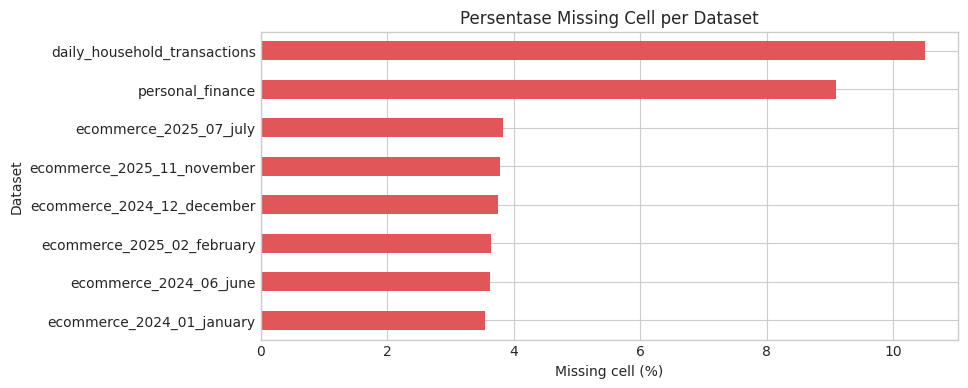

In [8]:
missing_rows = []
important_columns = ['tanggal_asli', 'amount', 'category', 'status', 'payment_method', 'city', 'province']

for dataset_id, frame in raw_datasets.items():
    analysis = analysis_datasets[dataset_id]
    total_cells = frame.shape[0] * frame.shape[1]
    row = {
        'dataset_id': dataset_id,
        'missing_cells': int(frame.isna().sum().sum()),
        'missing_cell_pct': round(frame.isna().sum().sum() / total_cells * 100, 2),
        'columns_with_missing': int((frame.isna().sum() > 0).sum()),
    }

    for column in important_columns:
        row[f'{column}_missing_pct'] = round(analysis[column].isna().mean() * 100, 2)

    missing_rows.append(row)

missing_summary_df = pd.DataFrame(missing_rows)
display(missing_summary_df)

plot_data = missing_summary_df.sort_values('missing_cell_pct')
ax = plot_data.plot(
    x='dataset_id', y='missing_cell_pct', kind='barh', legend=False, figsize=(9, 4), color='#e15759'
)
ax.set_title('Persentase Missing Cell per Dataset')
ax.set_xlabel('Missing cell (%)')
ax.set_ylabel('Dataset')
plt.show()


## 9. Top missing column per dataset

Tabel ini membantu menentukan kolom mana yang perlu diisi, di-drop, atau dibiarkan karena memang tidak relevan.


,dataset_id,column,missing_count,missing_pct
0,ecommerce_2024_01_january,Alasan Pembatalan,367,85.15
1,ecommerce_2024_06_june,Alasan Pembatalan,608,87.23
2,ecommerce_2024_12_december,Alasan Pembatalan,1047,86.24
3,ecommerce_2025_02_february,Alasan Pembatalan,835,87.25
4,ecommerce_2025_07_july,Alasan Pembatalan,676,88.25
5,ecommerce_2025_11_november,Alasan Pembatalan,1030,91.07
6,daily_household_transactions,_dataset_period,2461,100.00
7,daily_household_transactions,Subcategory,635,25.80
8,daily_household_transactions,Note,521,21.17
9,personal_finance,_dataset_period,1500,100.00


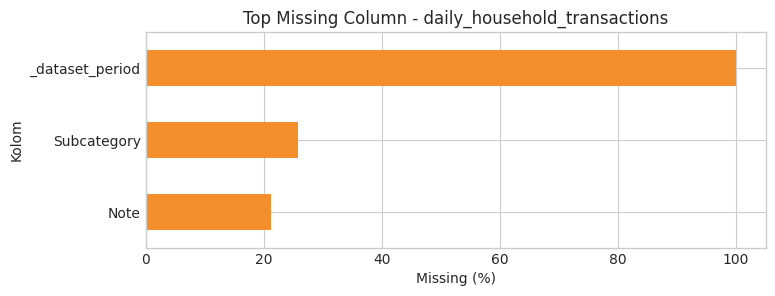

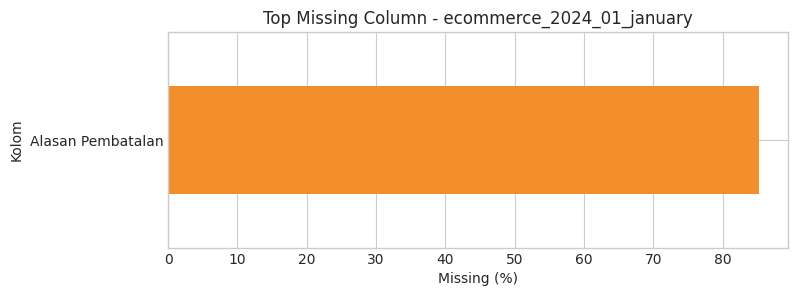

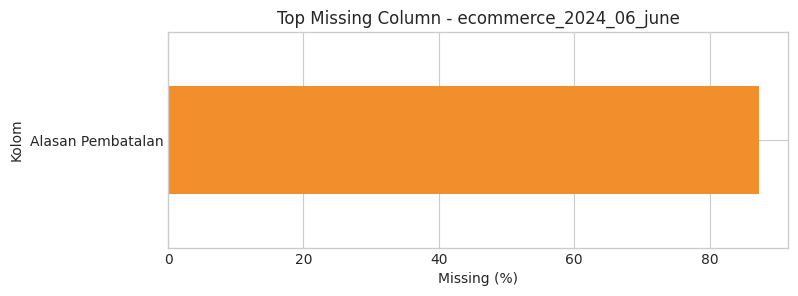

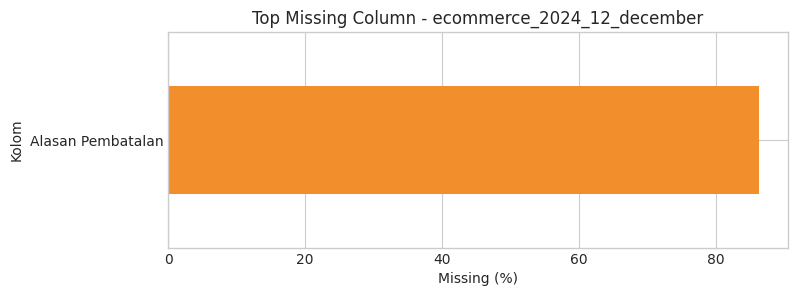

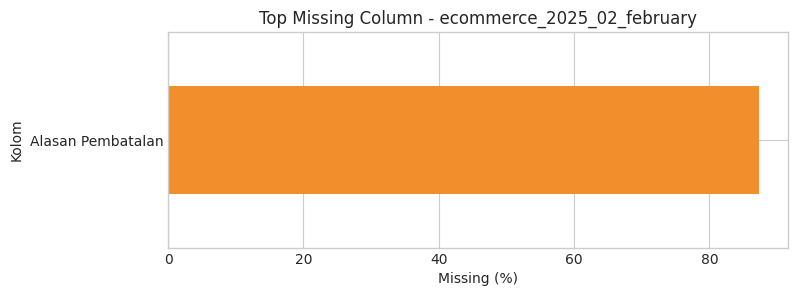

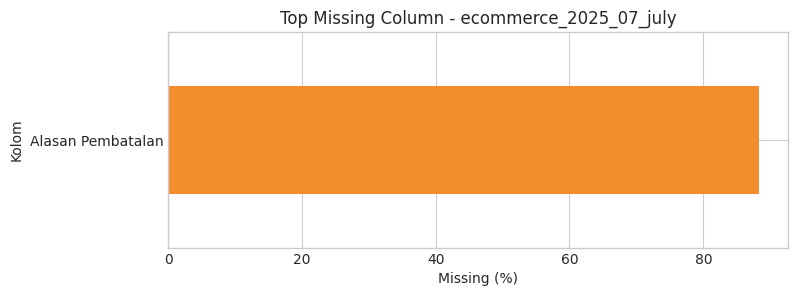

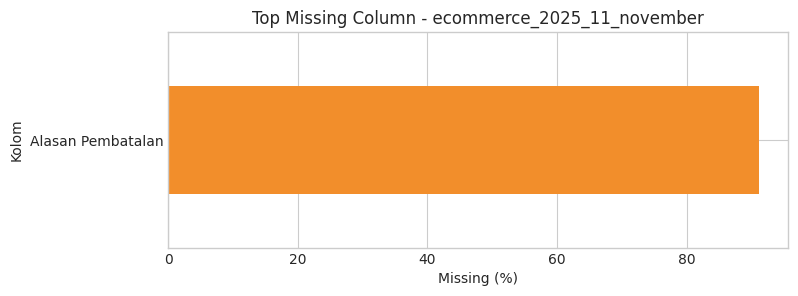

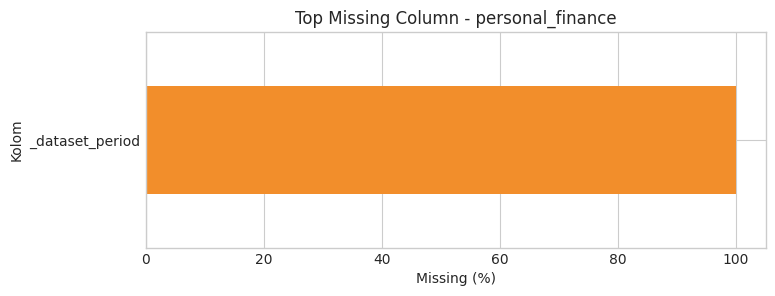

In [9]:
top_missing_rows = []

for dataset_id, frame in raw_datasets.items():
    missing = frame.isna().sum().reset_index()
    missing.columns = ['column', 'missing_count']
    missing['dataset_id'] = dataset_id
    missing['missing_pct'] = (missing['missing_count'] / len(frame) * 100).round(2)
    missing = missing[missing['missing_count'] > 0]
    top_missing_rows.append(missing.sort_values('missing_pct', ascending=False).head(6))

top_missing_df = pd.concat(top_missing_rows, ignore_index=True)
display(top_missing_df[['dataset_id', 'column', 'missing_count', 'missing_pct']])

for dataset_id, group in top_missing_df.groupby('dataset_id'):
    ax = group.sort_values('missing_pct').plot(
        x='column', y='missing_pct', kind='barh', legend=False, figsize=(8, 2.8), color='#f28e2b'
    )
    ax.set_title(f'Top Missing Column - {dataset_id}')
    ax.set_xlabel('Missing (%)')
    ax.set_ylabel('Kolom')
    plt.show()


## 10. Duplikasi data

Duplikasi dicek dengan dua cara:
- `exact_duplicates`: seluruh baris sama persis.
- `key_duplicates`: baris mirip berdasarkan key transaksi yang masuk akal untuk tiap pola dataset.


,dataset_id,exact_duplicates,key_duplicates
0,ecommerce_2024_01_january,0,0
1,ecommerce_2024_06_june,0,0
2,ecommerce_2024_12_december,0,0
3,ecommerce_2025_02_february,0,0
4,ecommerce_2025_07_july,0,0
5,ecommerce_2025_11_november,0,0
6,daily_household_transactions,9,29
7,personal_finance,0,0


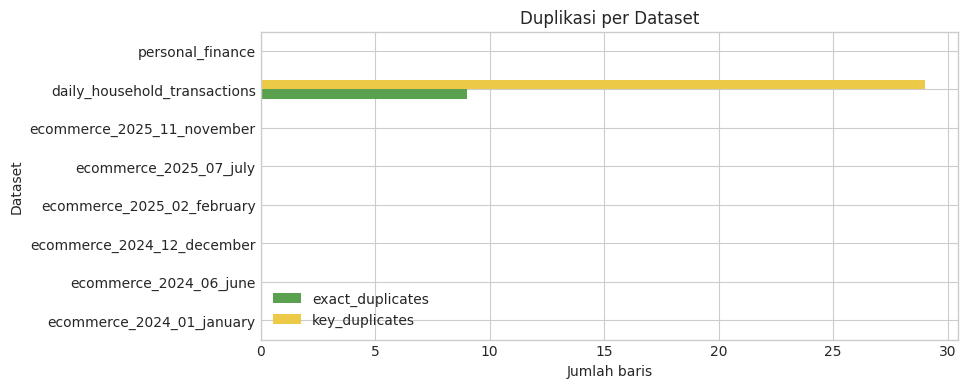

In [10]:
def hitung_key_duplicate(dataset_id, analysis):
    if analysis['domain'].iloc[0] == 'ecommerce_sales':
        key_columns = ['order_id']
    else:
        key_columns = ['tanggal', 'amount', 'category', 'description']

    return int(analysis.duplicated(subset=key_columns, keep=False).sum())


duplicate_rows = []

for dataset_id, frame in raw_datasets.items():
    analysis = analysis_datasets[dataset_id]
    duplicate_rows.append({
        'dataset_id': dataset_id,
        'exact_duplicates': int(frame.duplicated().sum()),
        'key_duplicates': hitung_key_duplicate(dataset_id, analysis),
    })

duplicate_summary_df = pd.DataFrame(duplicate_rows)
display(duplicate_summary_df)

plot_data = duplicate_summary_df.set_index('dataset_id')[['exact_duplicates', 'key_duplicates']]
ax = plot_data.plot(kind='barh', figsize=(9, 4), color=['#59a14f', '#edc948'])
ax.set_title('Duplikasi per Dataset')
ax.set_xlabel('Jumlah baris')
ax.set_ylabel('Dataset')
plt.show()


## 11. Statistik deskriptif amount

Statistik dihitung per dataset. Ini penting karena amount masih memakai mata uang asli atau skala asli masing-masing dataset, sehingga jangan langsung dibandingkan antar domain.


,dataset_id,min,q1,median,q3,max,mean,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,daily_household_transactions,2.00,35.00,100.000,799.0000,250000.0,2751.145380,764.0000,-1111.00000,1945.00000,315.0,12.80
1,ecommerce_2024_01_january,0.00,20800.00,30000.000,56120.0000,1292467.0,56827.102088,35320.0000,-32180.00000,109100.00000,36.0,8.35
2,ecommerce_2024_06_june,0.00,16444.00,21696.000,43353.0000,1202900.0,46579.519369,26909.0000,-23919.50000,83716.50000,72.0,10.33
3,ecommerce_2024_12_december,0.00,14467.00,21280.000,37800.0000,2692454.0,46178.136738,23333.0000,-20532.50000,72799.50000,117.0,9.64
4,ecommerce_2025_02_february,0.00,12652.00,20998.000,44000.0000,3023425.0,55473.381400,31348.0000,-34370.00000,91022.00000,115.0,12.02
5,ecommerce_2025_07_july,0.00,11400.00,19500.000,38225.0000,3403591.0,54363.656658,26825.0000,-28837.50000,78462.50000,92.0,12.01
6,ecommerce_2025_11_november,0.00,14819.00,18900.000,33044.0000,1415660.0,40131.132626,18225.0000,-12518.50000,60381.50000,125.0,11.05
7,personal_finance,14.37,629.34,1156.285,1712.9325,4996.0,1307.520913,1083.5925,-996.04875,3338.32125,88.0,5.87


/tmp/ipykernel_102465/1312306028.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels=labels, vert=False, showfliers=True)


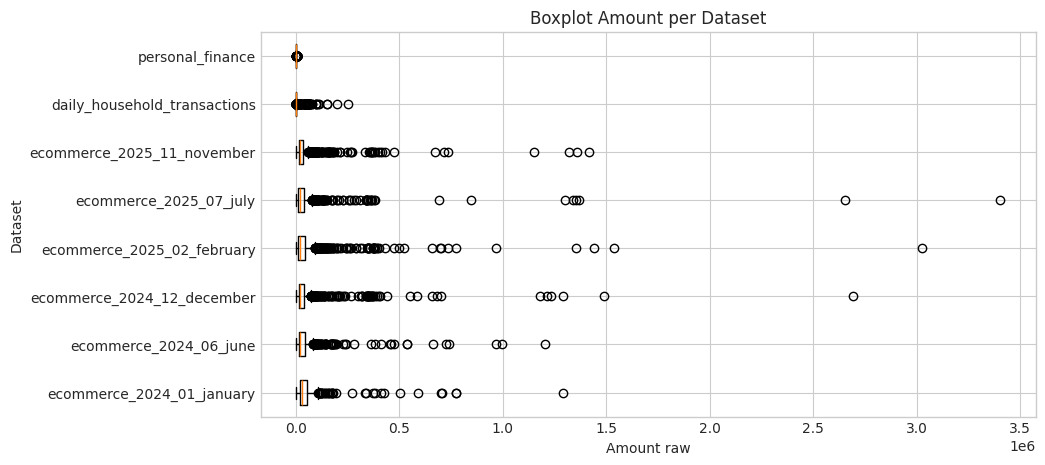

In [11]:
def hitung_iqr(series):
    angka = pd.to_numeric(series, errors='coerce').dropna()

    if angka.empty:
        return pd.Series({
            'min': np.nan, 'q1': np.nan, 'median': np.nan, 'q3': np.nan,
            'max': np.nan, 'mean': np.nan, 'iqr': np.nan,
            'lower_bound': np.nan, 'upper_bound': np.nan,
            'outlier_count': 0, 'outlier_pct': 0,
        })

    q1 = angka.quantile(0.25)
    median = angka.quantile(0.50)
    q3 = angka.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((angka < lower_bound) | (angka > upper_bound)).sum())

    return pd.Series({
        'min': angka.min(),
        'q1': q1,
        'median': median,
        'q3': q3,
        'max': angka.max(),
        'mean': angka.mean(),
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outlier_count,
        'outlier_pct': round(outlier_count / len(angka) * 100, 2),
    })


iqr_summary_df = (
    analysis_df.groupby('dataset_id')['amount']
    .apply(hitung_iqr)
    .unstack()
    .reset_index()
)

display(iqr_summary_df)

boxplot_data = [
    analysis_datasets[dataset_id]['amount'].dropna()
    for dataset_id in analysis_datasets
]
labels = list(analysis_datasets.keys())

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(boxplot_data, labels=labels, vert=False, showfliers=True)
ax.set_title('Boxplot Amount per Dataset')
ax.set_xlabel('Amount raw')
ax.set_ylabel('Dataset')
plt.show()


## 12. Cek outlier amount dengan IQR

Outlier tidak langsung dihapus di tahap assessing. Di sini hanya ditandai agar tahap cleaning bisa memutuskan apakah outlier perlu di-cap, dihapus, atau dibiarkan.


/tmp/ipykernel_102465/3280683445.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  analysis_outlier_df = pd.concat(analysis_with_outlier, ignore_index=True)
/tmp/ipykernel_102465/3280683445.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  analysis_outlier_df = pd.concat(analysis_with_outlier, ignore_index=True)


,dataset_id,outlier_count,total_rows,outlier_pct
0,daily_household_transactions,315,2461,12.8
1,ecommerce_2024_01_january,36,431,8.35
2,ecommerce_2024_06_june,72,697,10.33
3,ecommerce_2024_12_december,117,1214,9.64
4,ecommerce_2025_02_february,115,957,12.02
5,ecommerce_2025_07_july,92,766,12.01
6,ecommerce_2025_11_november,125,1131,11.05
7,personal_finance,88,1500,5.87


,dataset_id,tanggal,amount,category,status,description
5883,daily_household_transactions,2017-12-26 21:55:12,250000.0,Fixed Deposit,Transfer-Out,<NA>
6421,daily_household_transactions,2017-06-27 10:00:50,200000.0,Fixed Deposit,Transfer-Out,New FD opened for 3 years
5884,daily_household_transactions,2017-12-26 21:50:33,150000.0,Saving Bank account 1,Transfer-Out,<NA>
6100,daily_household_transactions,2017-10-10 00:00:00,150000.0,Share Market,Transfer-Out,Stock market
5856,daily_household_transactions,2018-01-04 00:00:00,113376.0,Maturity amount,Income,SIP Redemption
246,ecommerce_2024_01_january,2024-01-16 16:11:00,1292467.0,Seal / Baut / Roof,Selesai,ORD_0006802
80,ecommerce_2024_01_january,2024-01-03 18:04:00,774000.0,Lunch Box / Rantang,Selesai,ORD_0006636
79,ecommerce_2024_01_january,2024-01-03 18:02:00,772960.0,Lunch Box / Rantang,Selesai,ORD_0006635
53,ecommerce_2024_01_january,2024-01-02 00:46:00,705301.0,Nampan / Tray,Selesai,ORD_0006609
108,ecommerce_2024_01_january,2024-01-04 23:10:00,702000.0,Seal / Baut / Roof,Selesai,ORD_0006664


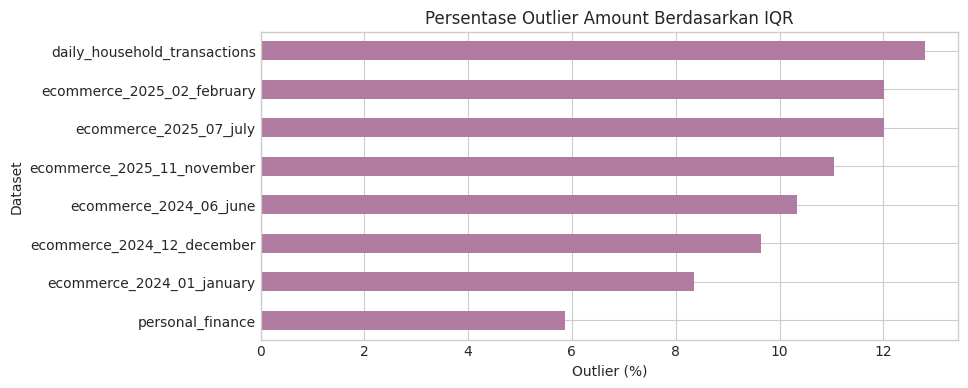

In [12]:
def tambah_flag_outlier(analysis, iqr_row):
    hasil = analysis.copy()
    lower_bound = iqr_row['lower_bound']
    upper_bound = iqr_row['upper_bound']
    hasil['is_outlier_amount'] = (hasil['amount'] < lower_bound) | (hasil['amount'] > upper_bound)
    return hasil


analysis_with_outlier = []
for dataset_id, analysis in analysis_datasets.items():
    iqr_row = iqr_summary_df.loc[iqr_summary_df['dataset_id'] == dataset_id].iloc[0]
    analysis_with_outlier.append(tambah_flag_outlier(analysis, iqr_row))

analysis_outlier_df = pd.concat(analysis_with_outlier, ignore_index=True)

outlier_summary_df = (
    analysis_outlier_df.groupby('dataset_id')['is_outlier_amount']
    .agg(outlier_count='sum', total_rows='count')
    .reset_index()
)
outlier_summary_df['outlier_pct'] = (outlier_summary_df['outlier_count'] / outlier_summary_df['total_rows'] * 100).round(2)

display(outlier_summary_df)

top_outliers_df = (
    analysis_outlier_df[analysis_outlier_df['is_outlier_amount']]
    .sort_values(['dataset_id', 'amount'], ascending=[True, False])
    .groupby('dataset_id')
    .head(5)
    [['dataset_id', 'tanggal', 'amount', 'category', 'status', 'description']]
)

display(top_outliers_df)

plot_data = outlier_summary_df.sort_values('outlier_pct')
ax = plot_data.plot(
    x='dataset_id', y='outlier_pct', kind='barh', legend=False, figsize=(9, 4), color='#b07aa1'
)
ax.set_title('Persentase Outlier Amount Berdasarkan IQR')
ax.set_xlabel('Outlier (%)')
ax.set_ylabel('Dataset')
plt.show()


## 13. Pola khusus e-commerce

Dataset e-commerce punya status pesanan, pembatalan, order id, quantity, dan lokasi. Status `Batal` dan amount 0 perlu diperhatikan sebelum data dipakai untuk analisis transaksi berhasil.


,dataset_id,status,rows
1,ecommerce_2024_01_january,Selesai,367
0,ecommerce_2024_01_january,Batal,64
3,ecommerce_2024_06_june,Selesai,608
2,ecommerce_2024_06_june,Batal,89
5,ecommerce_2024_12_december,Selesai,1047
4,ecommerce_2024_12_december,Batal,167
7,ecommerce_2025_02_february,Selesai,835
6,ecommerce_2025_02_february,Batal,122
9,ecommerce_2025_07_july,Selesai,676
8,ecommerce_2025_07_july,Batal,90


,dataset_id,zero_or_negative_amount_rows
0,ecommerce_2024_01_january,64
1,ecommerce_2024_06_june,89
2,ecommerce_2024_12_december,172
3,ecommerce_2025_02_february,126
4,ecommerce_2025_07_july,91
5,ecommerce_2025_11_november,109


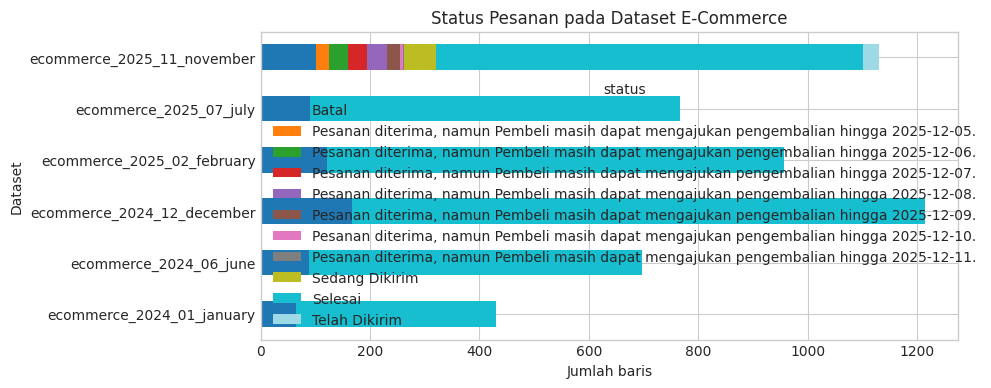

In [13]:
ecommerce_df = analysis_df[analysis_df['domain'] == 'ecommerce_sales'].copy()

ecommerce_status_df = (
    ecommerce_df.groupby(['dataset_id', 'status'])
    .size()
    .reset_index(name='rows')
    .sort_values(['dataset_id', 'rows'], ascending=[True, False])
)

ecommerce_zero_amount_df = (
    ecommerce_df.assign(zero_or_negative_amount=ecommerce_df['amount'].fillna(0) <= 0)
    .groupby('dataset_id')['zero_or_negative_amount']
    .sum()
    .reset_index(name='zero_or_negative_amount_rows')
)

display(ecommerce_status_df)
display(ecommerce_zero_amount_df)

status_pivot = ecommerce_status_df.pivot(index='dataset_id', columns='status', values='rows').fillna(0)
ax = status_pivot.plot(kind='barh', stacked=True, figsize=(9, 4), colormap='tab20')
ax.set_title('Status Pesanan pada Dataset E-Commerce')
ax.set_xlabel('Jumlah baris')
ax.set_ylabel('Dataset')
plt.show()


## 14. Pola khusus household dan personal finance

Dua dataset ini bukan data order e-commerce. Yang dicek adalah kategori, type/status transaksi, dan metode pembayaran bila tersedia.


,dataset_id,category,rows
18,daily_household_transactions,Food,907
44,daily_household_transactions,Transportation,307
23,daily_household_transactions,Household,176
48,daily_household_transactions,subscription,143
29,daily_household_transactions,Other,126
25,daily_household_transactions,Investment,103
22,daily_household_transactions,Health,94
15,daily_household_transactions,Family,71
1,daily_household_transactions,Apparel,47
32,daily_household_transactions,Recurring Deposit,47


,dataset_id,status,rows
0,daily_household_transactions,Expense,2176
2,daily_household_transactions,Transfer-Out,160
1,daily_household_transactions,Income,125
3,personal_finance,Expense,1222
4,personal_finance,Income,278


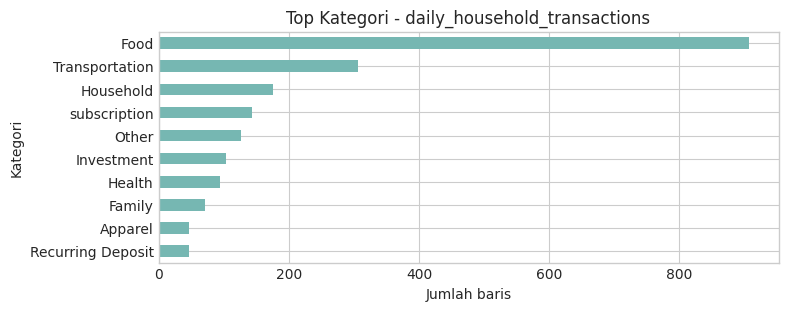

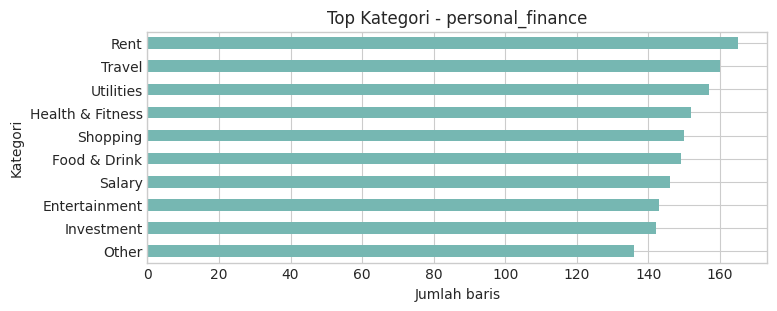

In [14]:
non_ecommerce_df = analysis_df[analysis_df['domain'] != 'ecommerce_sales'].copy()

category_non_ecom_df = (
    non_ecommerce_df.groupby(['dataset_id', 'category'])
    .size()
    .reset_index(name='rows')
    .sort_values(['dataset_id', 'rows'], ascending=[True, False])
)

status_non_ecom_df = (
    non_ecommerce_df.groupby(['dataset_id', 'status'])
    .size()
    .reset_index(name='rows')
    .sort_values(['dataset_id', 'rows'], ascending=[True, False])
)

display(category_non_ecom_df.groupby('dataset_id').head(10))
display(status_non_ecom_df)

for dataset_id, group in category_non_ecom_df.groupby('dataset_id'):
    top_group = group.head(10).sort_values('rows')
    ax = top_group.plot(x='category', y='rows', kind='barh', legend=False, figsize=(8, 3), color='#76b7b2')
    ax.set_title(f'Top Kategori - {dataset_id}')
    ax.set_xlabel('Jumlah baris')
    ax.set_ylabel('Kategori')
    plt.show()


## 15. Cek tanggal dan periode data

Tanggal dicek agar cleaning bisa menyamakan kolom `timestamp`. Khusus e-commerce yang tidak punya tanggal transaksi asli, notebook cleaning perlu memakai periode dataset sebagai fallback.


,dataset_id,min_date,max_date,original_date_missing_pct,date_from_period_rows
0,daily_household_transactions,2015-01-01 00:00:00,2018-09-20 12:04:08,0.0,0
1,ecommerce_2024_01_january,2024-01-01 00:05:00,2024-01-31 22:56:00,0.0,0
2,ecommerce_2024_06_june,2024-06-01 03:22:00,2024-06-30 23:36:00,0.0,0
3,ecommerce_2024_12_december,2024-12-01 00:00:00,2024-12-01 00:00:00,100.0,1214
4,ecommerce_2025_02_february,2025-02-01 00:40:00,2025-02-28 23:23:00,0.0,0
5,ecommerce_2025_07_july,2025-07-01 00:00:00,2025-07-01 00:00:00,100.0,766
6,ecommerce_2025_11_november,2025-11-01 06:08:00,2025-11-30 23:17:00,0.0,0
7,personal_finance,2020-01-02 00:00:00,2024-12-29 00:00:00,0.0,0


,dataset_id,year,rows
0,daily_household_transactions,2015,401
1,daily_household_transactions,2016,349
2,daily_household_transactions,2017,1035
3,daily_household_transactions,2018,676
4,ecommerce_2024_01_january,2024,431
5,ecommerce_2024_06_june,2024,697
6,ecommerce_2024_12_december,2024,1214
7,ecommerce_2025_02_february,2025,957
8,ecommerce_2025_07_july,2025,766
9,ecommerce_2025_11_november,2025,1131


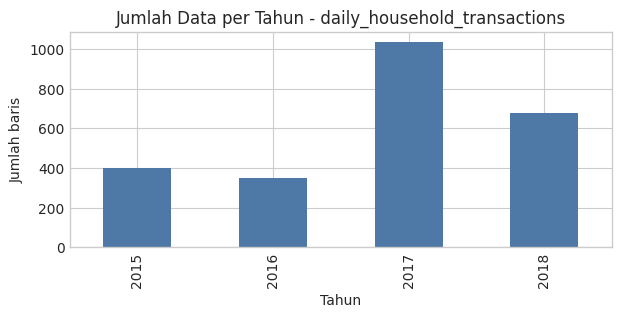

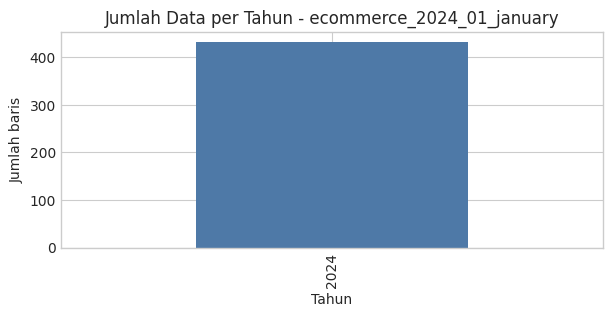

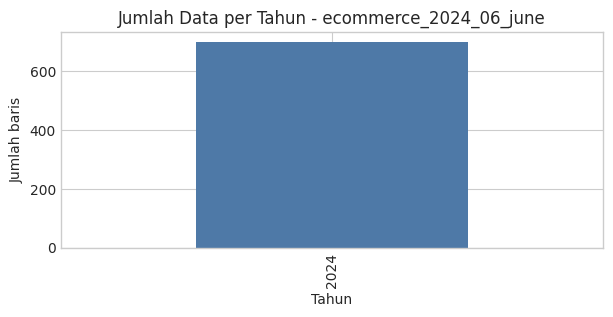

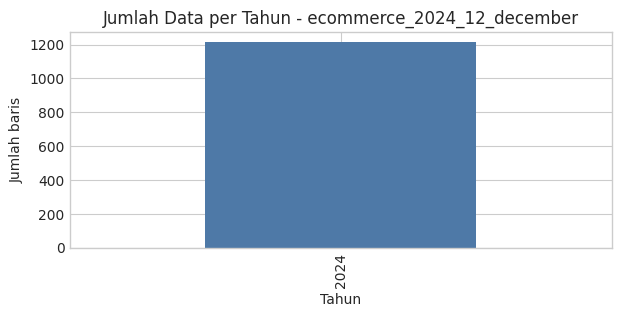

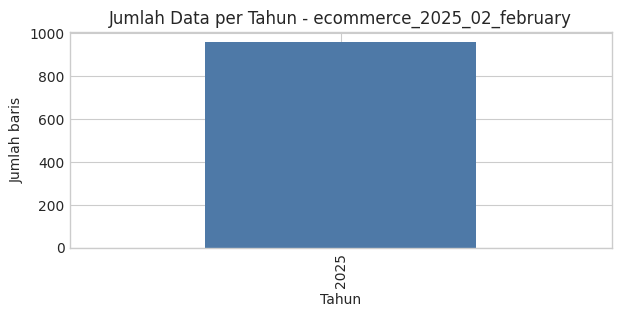

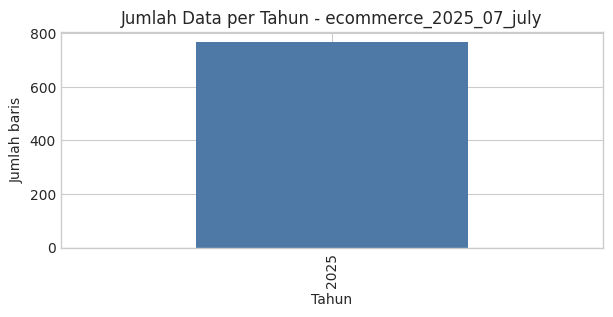

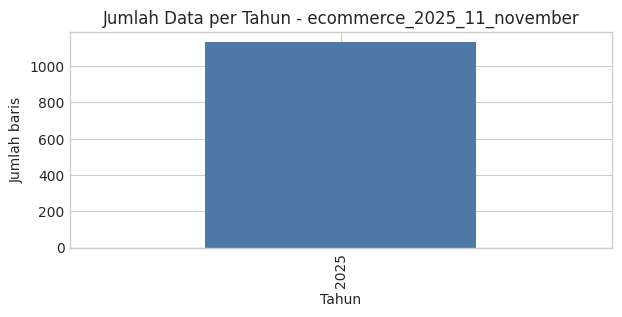

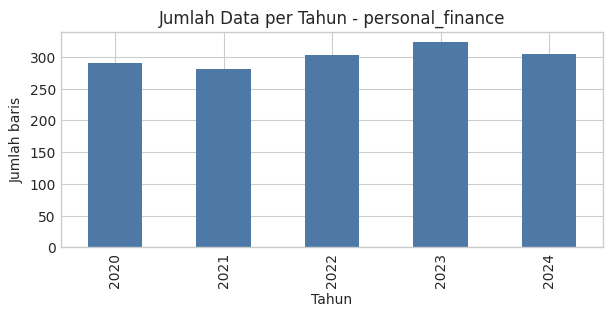

In [15]:
date_summary_df = (
    analysis_df.groupby('dataset_id')
    .agg(
        min_date=('tanggal', 'min'),
        max_date=('tanggal', 'max'),
        original_date_missing_pct=('tanggal_asli', lambda value: round(value.isna().mean() * 100, 2)),
        date_from_period_rows=('tanggal_dari_periode', 'sum'),
    )
    .reset_index()
)

display(date_summary_df)

analysis_df['year'] = analysis_df['tanggal'].dt.year
year_count_df = analysis_df.groupby(['dataset_id', 'year']).size().reset_index(name='rows')
display(year_count_df)

for dataset_id, group in year_count_df.groupby('dataset_id'):
    ax = group.plot(x='year', y='rows', kind='bar', legend=False, figsize=(7, 2.8), color='#4e79a7')
    ax.set_title(f'Jumlah Data per Tahun - {dataset_id}')
    ax.set_xlabel('Tahun')
    ax.set_ylabel('Jumlah baris')
    plt.show()


## 16. Rangkuman assessment per dataset

Tabel ini menggabungkan hasil utama: missing value, duplikasi, tanggal, amount nol, dan outlier. Ini menjadi checklist untuk cleaning.


In [16]:
assessment_summary_df = (
    load_summary_df[['dataset_id', 'dataset_name', 'domain', 'period', 'rows', 'columns']]
    .merge(missing_summary_df, on='dataset_id', how='left')
    .merge(duplicate_summary_df, on='dataset_id', how='left')
    .merge(iqr_summary_df[['dataset_id', 'q1', 'median', 'q3', 'iqr', 'lower_bound', 'upper_bound']], on='dataset_id', how='left')
    .merge(outlier_summary_df[['dataset_id', 'outlier_count', 'outlier_pct']], on='dataset_id', how='left')
    .merge(date_summary_df, on='dataset_id', how='left')
    .merge(ecommerce_zero_amount_df, on='dataset_id', how='left')
)

assessment_summary_df['zero_or_negative_amount_rows'] = assessment_summary_df['zero_or_negative_amount_rows'].fillna(0).astype(int)

display(assessment_summary_df)


,dataset_id,dataset_name,domain,period,rows,columns,missing_cells,missing_cell_pct,columns_with_missing,tanggal_asli_missing_pct,amount_missing_pct,category_missing_pct,status_missing_pct,payment_method_missing_pct,city_missing_pct,province_missing_pct,exact_duplicates,key_duplicates,q1,median,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,min_date,max_date,original_date_missing_pct,date_from_period_rows,zero_or_negative_amount_rows
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,2024-01,431,24,367,3.55,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,20800.00,30000.000,56120.0000,35320.0000,-32180.00000,109100.00000,36,8.35,2024-01-01 00:05:00,2024-01-31 22:56:00,0.0,0,64
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,2024-06,697,24,608,3.63,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,16444.00,21696.000,43353.0000,26909.0000,-23919.50000,83716.50000,72,10.33,2024-06-01 03:22:00,2024-06-30 23:36:00,0.0,0,89
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,2024-12,1214,23,1047,3.75,1,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,14467.00,21280.000,37800.0000,23333.0000,-20532.50000,72799.50000,117,9.64,2024-12-01 00:00:00,2024-12-01 00:00:00,100.0,1214,172
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,2025-02,957,24,835,3.64,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,12652.00,20998.000,44000.0000,31348.0000,-34370.00000,91022.00000,115,12.02,2025-02-01 00:40:00,2025-02-28 23:23:00,0.0,0,126
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,2025-07,766,23,676,3.84,1,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,11400.00,19500.000,38225.0000,26825.0000,-28837.50000,78462.50000,92,12.01,2025-07-01 00:00:00,2025-07-01 00:00:00,100.0,766,91
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,2025-11,1131,24,1030,3.79,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,14819.00,18900.000,33044.0000,18225.0000,-12518.50000,60381.50000,125,11.05,2025-11-01 06:08:00,2025-11-30 23:17:00,0.0,0,109
6,daily_household_transactions,Daily Household Transactions,household_finance,<NA>,2461,14,3617,10.50,3,0.0,0.0,0.0,0.0,0.0,100.0,100.0,9,29,35.00,100.000,799.0000,764.0000,-1111.00000,1945.00000,315,12.8,2015-01-01 00:00:00,2018-09-20 12:04:08,0.0,0,0
7,personal_finance,Personal Finance Dataset,personal_finance,<NA>,1500,11,1500,9.09,1,0.0,0.0,0.0,0.0,100.0,100.0,100.0,0,0,629.34,1156.285,1712.9325,1083.5925,-996.04875,3338.32125,88,5.87,2020-01-02 00:00:00,2024-12-29 00:00:00,0.0,0,0


## 17. Rekomendasi cleaning

Cell ini mengubah hasil assessment menjadi daftar aksi sederhana untuk notebook 03.


In [17]:
def buat_rekomendasi(row):
    rekomendasi = []

    if row['missing_cell_pct'] > 0:
        rekomendasi.append('cek missing value dan isi/drop sesuai makna kolom')
    if row['original_date_missing_pct'] > 0:
        rekomendasi.append('perbaiki timestamp; gunakan periode dataset jika tanggal asli tidak ada')
    if row['zero_or_negative_amount_rows'] > 0:
        rekomendasi.append('hapus/tandai transaksi batal atau amount 0')
    if row['exact_duplicates'] > 0 or row['key_duplicates'] > 0:
        rekomendasi.append('hapus duplikasi')
    if row['outlier_count'] > 0:
        rekomendasi.append('review outlier amount dengan batas IQR')

    if row['domain'] == 'ecommerce_sales':
        rekomendasi.append('standarkan status pesanan, kategori produk, lokasi, quantity, dan order_id')
    elif row['domain'] == 'household_finance':
        rekomendasi.append('standarkan kategori household dan konversi INR ke IDR bila digabung')
    elif row['domain'] == 'personal_finance':
        rekomendasi.append('standarkan type/category personal finance dan konversi USD ke IDR bila digabung')

    return '; '.join(rekomendasi)


recommendation_df = assessment_summary_df[['dataset_id', 'domain', 'rows']].copy()
recommendation_df['cleaning_action'] = assessment_summary_df.apply(buat_rekomendasi, axis=1)

display(recommendation_df)

for _, row in recommendation_df.iterrows():
    print(f"{row['dataset_id']}: {row['cleaning_action']}")


,dataset_id,domain,rows,cleaning_action
0,ecommerce_2024_01_january,ecommerce_sales,431,cek missing value dan isi/drop sesuai makna ko...
1,ecommerce_2024_06_june,ecommerce_sales,697,cek missing value dan isi/drop sesuai makna ko...
2,ecommerce_2024_12_december,ecommerce_sales,1214,cek missing value dan isi/drop sesuai makna ko...
3,ecommerce_2025_02_february,ecommerce_sales,957,cek missing value dan isi/drop sesuai makna ko...
4,ecommerce_2025_07_july,ecommerce_sales,766,cek missing value dan isi/drop sesuai makna ko...
5,ecommerce_2025_11_november,ecommerce_sales,1131,cek missing value dan isi/drop sesuai makna ko...
6,daily_household_transactions,household_finance,2461,cek missing value dan isi/drop sesuai makna ko...
7,personal_finance,personal_finance,1500,cek missing value dan isi/drop sesuai makna ko...


ecommerce_2024_01_january: cek missing value dan isi/drop sesuai makna kolom; hapus/tandai transaksi batal atau amount 0; review outlier amount dengan batas IQR; standarkan status pesanan, kategori produk, lokasi, quantity, dan order_id
ecommerce_2024_06_june: cek missing value dan isi/drop sesuai makna kolom; hapus/tandai transaksi batal atau amount 0; review outlier amount dengan batas IQR; standarkan status pesanan, kategori produk, lokasi, quantity, dan order_id
ecommerce_2024_12_december: cek missing value dan isi/drop sesuai makna kolom; perbaiki timestamp; gunakan periode dataset jika tanggal asli tidak ada; hapus/tandai transaksi batal atau amount 0; review outlier amount dengan batas IQR; standarkan status pesanan, kategori produk, lokasi, quantity, dan order_id
ecommerce_2025_02_february: cek missing value dan isi/drop sesuai makna kolom; hapus/tandai transaksi batal atau amount 0; review outlier amount dengan batas IQR; standarkan status pesanan, kategori produk, lokasi, qua

## 18. Simpan output assessment

Output disimpan agar notebook cleaning dan dokumentasi bisa memakai ringkasan yang sama.


In [18]:
assessment_summary_path = interim_path / 'assessment_summary_by_dataset.csv'
outlier_summary_path = interim_path / 'assessment_outlier_iqr_by_dataset.csv'
recommendation_path = interim_path / 'assessment_cleaning_recommendations.csv'
text_report_path = reports_path / '02_data_quality_report_by_dataset.txt'

assessment_summary_df.to_csv(assessment_summary_path, index=False)
outlier_summary_df.to_csv(outlier_summary_path, index=False)
recommendation_df.to_csv(recommendation_path, index=False)

report_lines = ['DATA ASSESSING SUMMARY - 8 DATASET', '']
for _, row in recommendation_df.iterrows():
    report_lines.append(f"{row['dataset_id']}")
    report_lines.append(f"Rows   : {row['rows']}")
    report_lines.append(f"Domain : {row['domain']}")
    report_lines.append(f"Action : {row['cleaning_action']}")
    report_lines.append('')

text_report_path.write_text(chr(10).join(report_lines), encoding='utf-8')

print('Assessment summary saved to:', assessment_summary_path)
print('Outlier summary saved to   :', outlier_summary_path)
print('Recommendation saved to    :', recommendation_path)
print('Text report saved to       :', text_report_path)


Assessment summary saved to: /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/interim/assessment_summary_by_dataset.csv
Outlier summary saved to   : /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/interim/assessment_outlier_iqr_by_dataset.csv
Recommendation saved to    : /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/interim/assessment_cleaning_recommendations.csv
Text report saved to       : /home/umaygans/05_nayyara_submission_1/nayyara_capstone/reports/02_data_quality_report_by_dataset.txt


## 19. Variabel penting

Variabel yang bisa dipakai ulang:
- `raw_datasets`: dictionary dataset mentah per dataset id.
- `analysis_datasets`: dictionary dataset versi analisis yang sudah diseragamkan.
- `analysis_df`: gabungan ringan untuk assessment.
- `missing_summary_df`: ringkasan missing value.
- `duplicate_summary_df`: ringkasan duplikasi.
- `iqr_summary_df`: statistik deskriptif dan batas IQR amount.
- `outlier_summary_df`: jumlah outlier amount per dataset.
- `assessment_summary_df`: rangkuman utama assessment.
- `recommendation_df`: daftar aksi cleaning untuk notebook 03.
